# 09 - Tópicos Especiais

- Auto Arima com X
- Prophet
- Tratamento de outliers (além de criação de eventos)
- Considerações para modelos hierárquicos
- Redes Neurais, Gradient Boosting e outros métodos ML
- Métodos de cross-validation para séries temporais

In [44]:
from pathlib import Path
import warnings
warnings.simplefilter(action="ignore", category=FutureWarning)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima


from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from funcoes import all_ac, plot_forecast, teste_estacionariedade, diagnostico, compara_previsoes, correlacao_cruzada, compara_estatisticas

plt.rcParams["figure.figsize"] = [12, 5]

## Auto ARIMA com X

In [45]:
df = pd.read_csv('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/clicks_original.csv')
df.index = pd.to_datetime(df['date'], format='mixed')
df = df.drop(['date'], axis=1)
df.index.freq = 'D'
df = df[:-1] # Tirando o último ponto por ser um outlier, vou discutir isso depois
df['price_4'] = df['price'].shift(4)
df = df.dropna()
y = df['clicks']
x = df['price_4']
x

date
2008-04-05    43.155647
2008-04-06    43.079056
2008-04-07    43.842609
2008-04-08    43.312376
2008-04-09    43.941176
                ...    
2008-08-08    44.237583
2008-08-09    43.801770
2008-08-10    43.917176
2008-08-11    44.254605
2008-08-12    43.730836
Freq: D, Name: price_4, Length: 130, dtype: float64

Auto Arima necessita de um array 2d, transformando:

In [46]:
x = x.values.reshape(-1, 1)
x

array([[43.15564682],
       [43.07905583],
       [43.84260922],
       [43.31237591],
       [43.94117647],
       [44.40393627],
       [43.99588759],
       [43.37377342],
       [43.3203125 ],
       [43.15473756],
       [42.92165899],
       [42.71320755],
       [43.54693367],
       [44.4093473 ],
       [42.20701754],
       [43.18156028],
       [44.05149254],
       [42.34208754],
       [42.2296764 ],
       [43.30626655],
       [43.24743777],
       [42.87278583],
       [43.53069153],
       [43.41507634],
       [42.26779661],
       [42.41653418],
       [44.22765197],
       [42.64935065],
       [42.37521968],
       [42.90316004],
       [43.22430939],
       [44.03172205],
       [43.03038674],
       [43.10958904],
       [43.87172012],
       [43.56942949],
       [42.98898072],
       [42.45890411],
       [42.87135922],
       [42.5762987 ],
       [43.40588988],
       [43.25832583],
       [42.71447903],
       [43.37278583],
       [42.51775487],
       [44

In [47]:
auto_model = auto_arima(y, X=x,
                           information_criterion='bic',
                           trace=True)

Performing stepwise search to minimize bic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : BIC=inf, Time=0.09 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=2596.044, Time=0.00 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=2591.052, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=2593.636, Time=0.01 sec
 ARIMA(0,1,0)(0,0,0)[0]             : BIC=2591.284, Time=0.02 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : BIC=2593.403, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=2597.256, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : BIC=2600.978, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[0]             : BIC=2586.271, Time=0.01 sec
 ARIMA(2,1,0)(0,0,0)[0]             : BIC=2588.747, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[0]             : BIC=2533.463, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[0]             : BIC=2589.056, Time=0.01 sec
 ARIMA(2,1,1)(0,0,0)[0]             : BIC=2596.424, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[0]             : BIC=inf, Time=0.07 sec
 ARIMA(0,1,2)(0,0,0)[0]             : BIC=2

In [48]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  130
Model:               SARIMAX(1, 1, 1)   Log Likelihood               -1257.012
Date:                Mon, 31 Mar 2025   AIC                           2522.023
Time:                        14:50:39   BIC                           2533.463
Sample:                    04-05-2008   HQIC                          2526.671
                         - 08-12-2008                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1           280.6459    203.660      1.378      0.168    -118.521     679.813
ar.L1         -0.0011      0.105     -0.010      0.992      -0.207       0.205
ma.L1         -0.8966      0.046    -19.450      0.000      -0.987      -0.806
sigma2      1.703e+07      0.011   1.49e+09      0.000     1.7e+07     1.7e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               143.46
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               1.09   Skew:                             1.48
Prob(H) (two-sided):                  0.78   Kurtosis:                         7.23
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.21e+24. Standard errors may be unstable.
"""

In [49]:
x = df[['price', 'price_4']]
x

,price,price_4
date,,
2008-04-05,43.941176,43.155647
2008-04-06,44.403936,43.079056
2008-04-07,43.995888,43.842609
2008-04-08,43.373773,43.312376
2008-04-09,43.320312,43.941176
...,...,...
2008-08-08,43.730836,44.237583
2008-08-09,44.182033,43.801770
2008-08-10,43.608260,43.917176


In [50]:
auto_model = auto_arima(y, X=x,
                           information_criterion='bic',
                           trace=True)

Performing stepwise search to minimize bic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : BIC=inf, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=2548.227, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : BIC=2549.530, Time=0.01 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : BIC=2549.926, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=2543.361, Time=0.01 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : BIC=2550.749, Time=0.03 sec

Best model:  ARIMA(0,0,0)(0,0,0)[0]          
Total fit time: 0.130 seconds


In [51]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  130
Model:                        SARIMAX   Log Likelihood               -1264.379
Date:                Mon, 31 Mar 2025   AIC                           2534.759
Time:                        14:50:39   BIC                           2543.361
Sample:                    04-05-2008   HQIC                          2538.254
                         - 08-12-2008                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
price      -1285.2628    411.116     -3.126      0.002   -2091.035    -479.490
price_4     1497.7165    411.910      3.636      0.000     690.389    2305.044
sigma2      1.634e+07   1.88e+06      8.692      0.000    1.27e+07       2e+07
===================================================================================
Ljung-Box (L1) (Q):                   3.60   Jarque-Bera (JB):                92.09
Prob(Q):                              0.06   Prob(JB):                         0.00
Heteroskedasticity (H):               0.85   Skew:                             1.45
Prob(H) (two-sided):                  0.61   Kurtosis:                         5.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

## Último exemplo de Auto ARIMA

In [52]:
file = Path('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/closing_price.csv')
closing_price = pd.read_csv(file, index_col='Date',parse_dates=True).resample('D').mean()
apple = pd.Series(closing_price['AAPL'], name='Preço de Fechamento Apple')
microsoft = pd.Series(closing_price['MSFT'], name='Preço de Fechamento Microsoft')
ibm = pd.Series(closing_price['IBM'], name='Preço de Fechamento IBM')

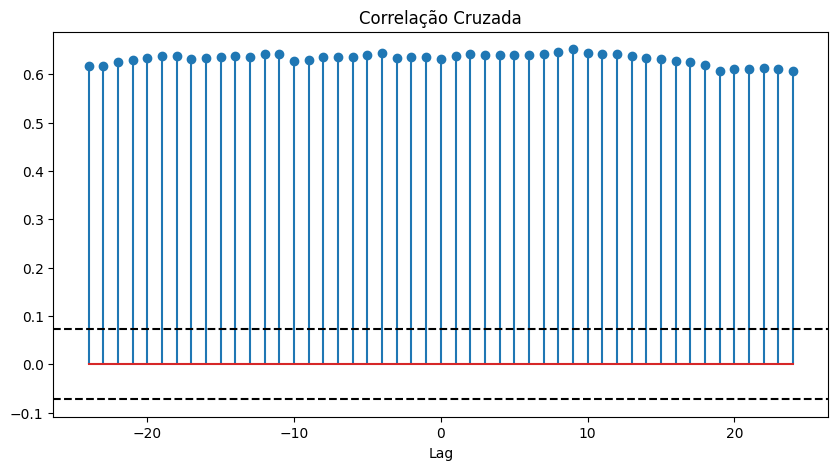

In [53]:
correlacao_cruzada(microsoft, ibm)

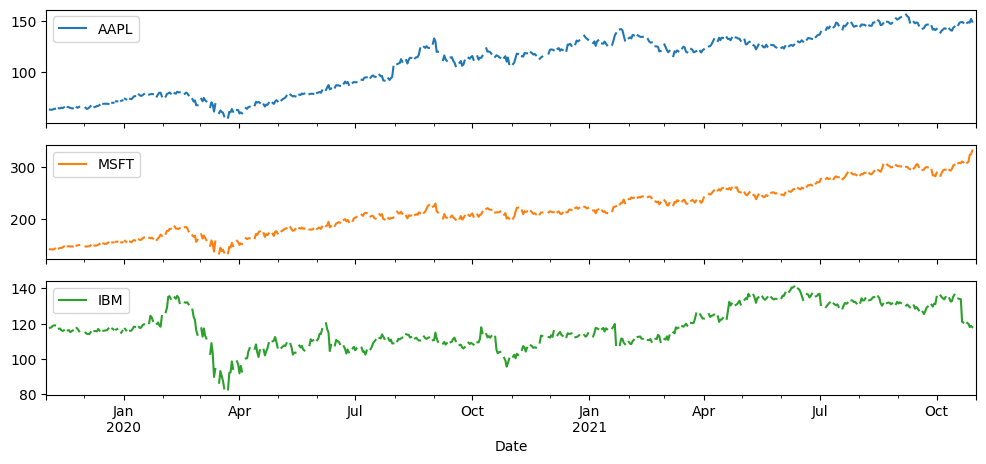

In [54]:
closing_price.plot(subplots=True)
plt.show()

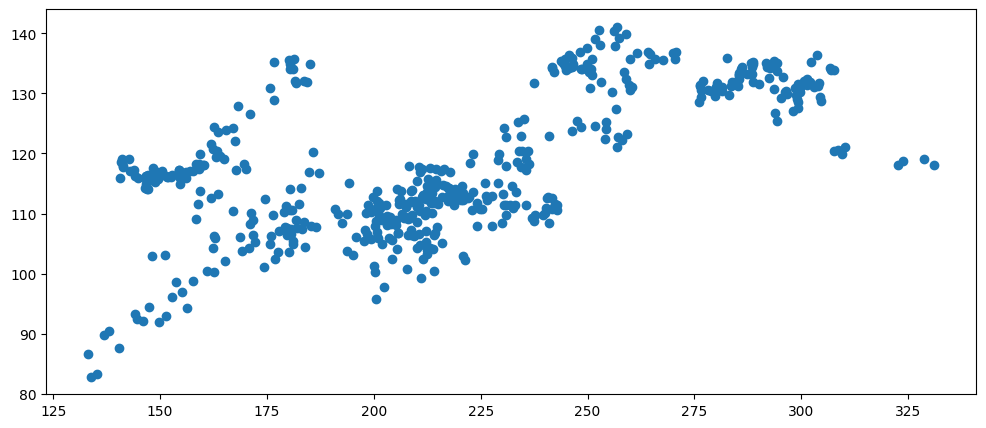

In [55]:
plt.scatter(x=microsoft, y=ibm)
plt.show()

In [56]:
primeira_ordem = closing_price.diff(1).dropna()
primeira_ordem

,AAPL,MSFT,IBM
Date,,,
2019-11-05,-0.090874,-0.087997,0.188065
2019-11-06,0.027004,-0.391220,0.760742
2019-11-07,0.729172,0.195602,0.458366
2019-11-08,0.174904,1.662537,-0.069199
2019-11-12,-0.059135,0.938858,0.103790
...,...,...,...
2021-10-22,-0.788834,-1.597076,-0.424545
2021-10-26,0.679016,1.976349,-0.481155
2021-10-27,-0.469315,13.036194,-1.849129


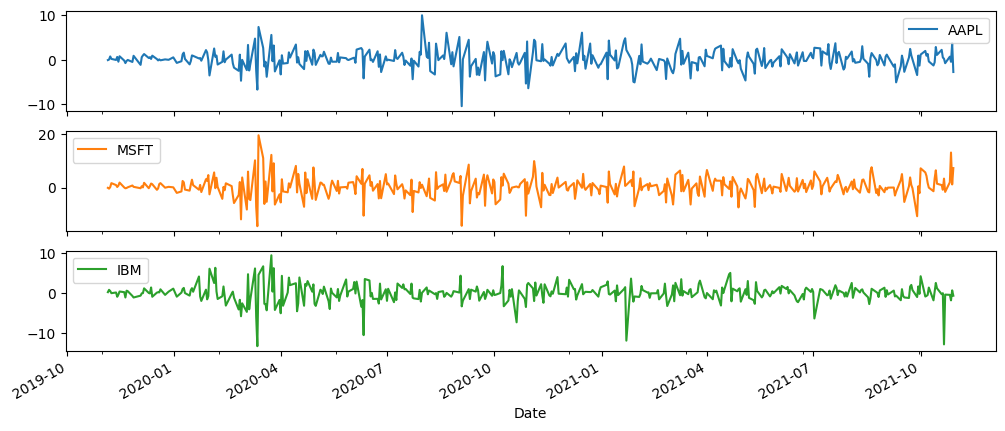

In [57]:
primeira_ordem.plot(subplots=True) 
plt.show()

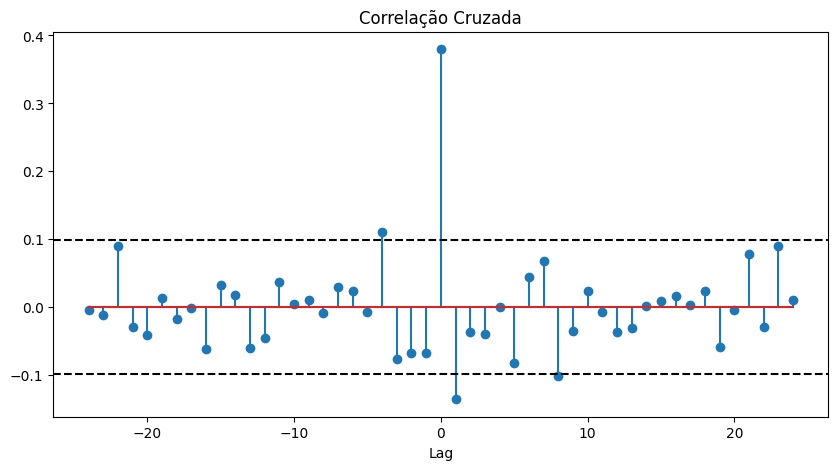

In [58]:
correlacao_cruzada(primeira_ordem['MSFT'], primeira_ordem['IBM'])

In [59]:
primeira_ordem['IBM_1'] = primeira_ordem['IBM'].shift(1)
primeira_ordem = primeira_ordem.dropna()
primeira_ordem

,AAPL,MSFT,IBM,IBM_1
Date,,,,
2019-11-06,0.027004,-0.391220,0.760742,0.188065
2019-11-07,0.729172,0.195602,0.458366,0.760742
2019-11-08,0.174904,1.662537,-0.069199,0.458366
2019-11-12,-0.059135,0.938858,0.103790,-0.069199
2019-11-13,0.618324,0.234726,-0.960014,0.103790
...,...,...,...,...
2021-10-22,-0.788834,-1.597076,-0.424545,-12.802399
2021-10-26,0.679016,1.976349,-0.481155,-0.424545
2021-10-27,-0.469315,13.036194,-1.849129,-0.481155


In [60]:
y = primeira_ordem['MSFT']
x = primeira_ordem['IBM_1'].values.reshape(-1, 1)
auto_model = auto_arima(y, X=x,
                           information_criterion='bic',
                           trace=True)

Performing stepwise search to minimize bic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : BIC=2182.517, Time=0.06 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : BIC=2172.259, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : BIC=2172.450, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : BIC=2170.700, Time=0.02 sec
 ARIMA(0,0,0)(0,0,0)[0]             : BIC=2170.966, Time=0.02 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : BIC=2174.482, Time=0.03 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : BIC=2173.280, Time=0.03 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : BIC=2177.067, Time=0.05 sec
 ARIMA(0,0,1)(0,0,0)[0]             : BIC=2171.378, Time=0.02 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 0.314 seconds


In [61]:
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  393
Model:               SARIMAX(0, 0, 1)   Log Likelihood               -1073.402
Date:                Mon, 31 Mar 2025   AIC                           2154.805
Time:                        14:50:40   BIC                           2170.700
Sample:                             0   HQIC                          2161.104
                                - 393                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.4123      0.162      2.548      0.011       0.095       0.729
x1            -0.1358      0.068     -2.010      0.044      -0.268      -0.003
ma.L1         -0.1647      0.045     -3.646      0.000      -0.253      -0.076
sigma2        13.7999      0.661     20.865      0.000      12.504      15.096
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):               104.05
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               0.65   Skew:                            -0.11
Prob(H) (two-sided):                  0.02   Kurtosis:                         5.51
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Último mesmo

In [62]:
milk_file = Path('/Users/danielferreira/Documents/git/classes/ASN/Séries Temporais/dados/milk_production.csv')

milk_prod = pd.read_csv(milk_file, 
                   index_col='month', 
                   parse_dates=True)
periodos = 24
train = milk_prod[:-periodos]
test = milk_prod[-periodos:]
train

,production
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727
...,...
1973-08-01,837
1973-09-01,784
1973-10-01,791


In [63]:
auto_model = auto_arima(train, 
                           seasonal=True, 
                           m=12, 
                           test='adf',
                           stepwise=True)
auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  144
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -451.814
Date:                            Mon, 31 Mar 2025   AIC                            909.628
Time:                                    14:50:42   BIC                            918.253
Sample:                                01-01-1962   HQIC                           913.133
                                     - 12-01-1973                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2784      0.084     -3.309      0.001      -0.443      -0.114
ma.S.L12      -0.6361      0.082     -7.765      0.000      -0.797      -0.476
sigma2        55.2574      5.688      9.716      0.000      44.110      66.405
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                34.99
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               1.16   Skew:                             0.80
Prob(H) (two-sided):                  0.63   Kurtosis:                         4.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

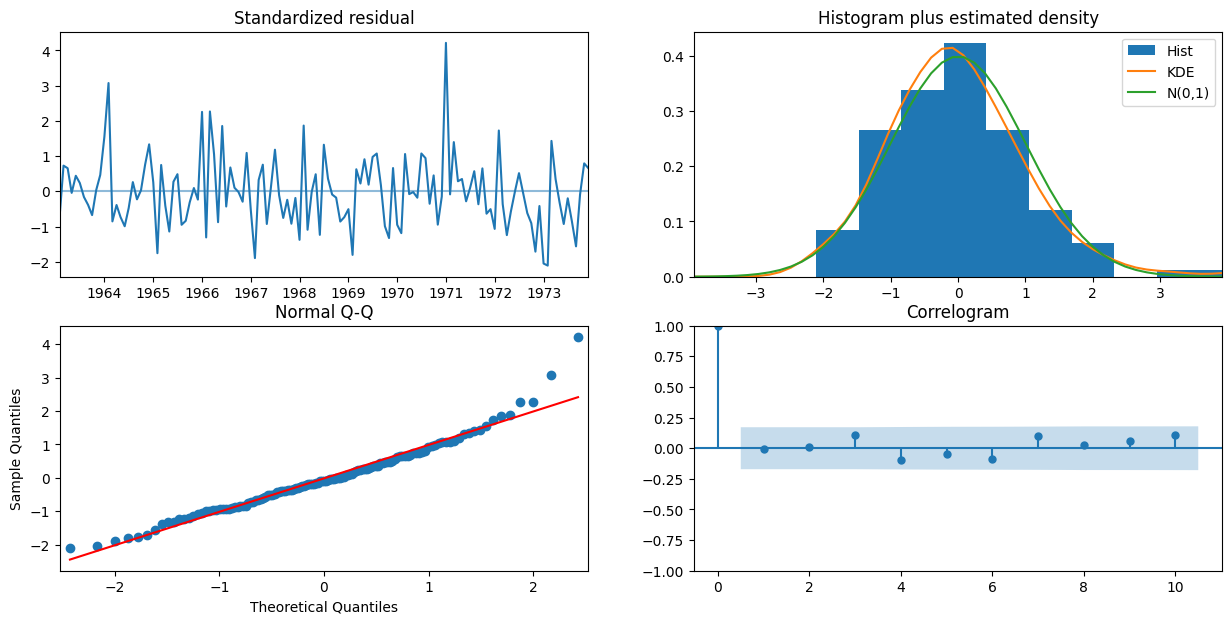

In [64]:
auto_model.plot_diagnostics(figsize=(15,7)); plt.show()

In [65]:
auto_model

ARIMA(order=(0, 1, 1), scoring_args={}, seasonal_order=(0, 1, 1, 12),
      suppress_warnings=True, with_intercept=False)

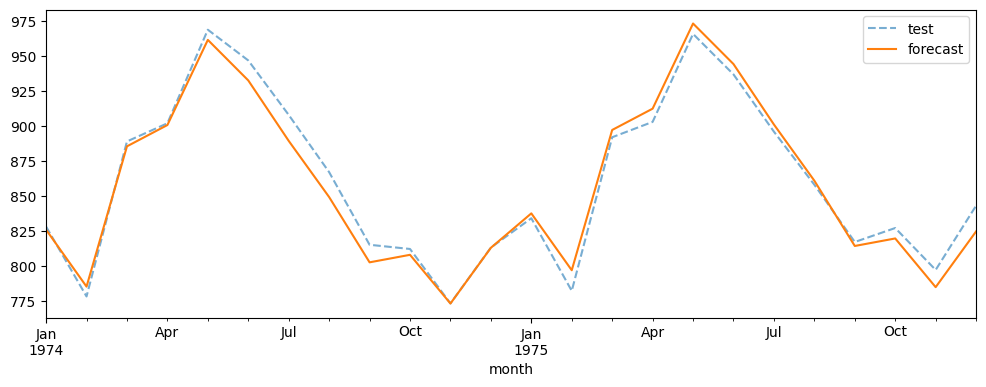

In [66]:
n = test.shape[0]
index = test.index
ax = test.plot(style='--', alpha=0.6, figsize=(12,4))
pd.Series(auto_model.predict(n_periods=n), 
          index=index).plot(style='-', ax=ax)
plt.legend(['test', 'forecast']); plt.show()

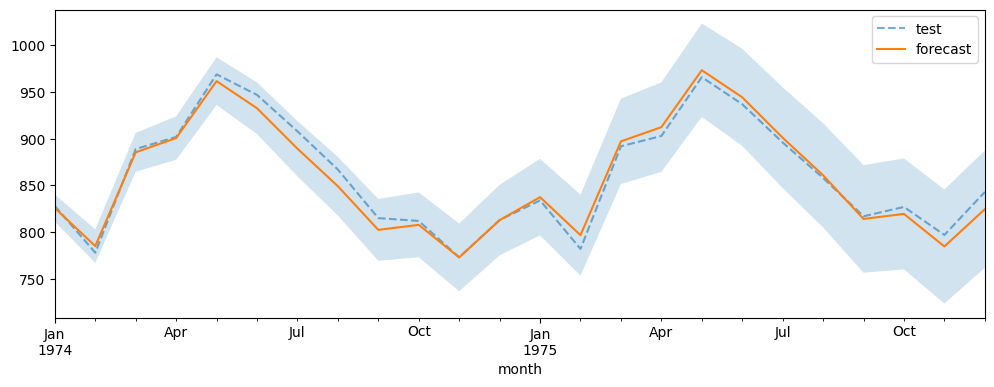

In [67]:
n = test.shape[0]
forecast, conf_interval = auto_model.predict(n_periods=n, return_conf_int=True)
lower_ci, upper_ci  = zip(*conf_interval)

index = test.index
ax = test.plot(style='--', alpha=0.6, figsize=(12,4))
pd.Series(forecast, index=index).plot(style='-', ax=ax)
plt.fill_between(index, lower_ci, upper_ci, alpha=0.2)
plt.legend(['test', 'forecast']); plt.show()

## Prophet

$$
\large Y_t = g_t + s_t + h_t + \epsilon _t
$$

$$
\large y(t) = g(t) + s(t) + h(t) + \epsilon _t
$$



In [68]:
from prophet import Prophet

In [69]:
milk_file = Path(milk_file)
milk = pd.read_csv(milk_file, parse_dates=['month'])
milk.columns = ['ds', 'y']
milk

,ds,y
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727
...,...,...
163,1975-08-01,858
164,1975-09-01,817
165,1975-10-01,827
166,1975-11-01,797


In [70]:
periodos = 24
train = milk[:-periodos]
test = milk[-periodos:]
train

,ds,y
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727
...,...,...
139,1973-08-01,837
140,1973-09-01,784
141,1973-10-01,791
142,1973-11-01,760


In [71]:
model = Prophet().fit(train)

14:50:43 - cmdstanpy - INFO - Chain [1] start processing
14:50:43 - cmdstanpy - INFO - Chain [1] done processing


In [72]:
model.seasonalities

OrderedDict([('yearly',
              {'period': 365.25,
               'fourier_order': 10,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None})])

In [73]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [74]:
future = model.make_future_dataframe(len(test), freq='MS')

In [75]:
len(milk) == len(future)

True

In [76]:
forecast = model.predict(future)

In [77]:
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [78]:
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']

In [79]:
forecast[cols].head()

,ds,yhat,yhat_lower,yhat_upper
0,1962-01-01,587.851494,578.628111,596.870733
1,1962-02-01,549.058806,539.733728,558.649030
2,1962-03-01,641.386517,631.758346,649.965960
3,1962-04-01,659.443018,650.835115,668.662157
4,1962-05-01,721.851378,712.970913,730.924183


In [80]:
pd.concat([forecast['yhat'].iloc[0:5], train['y'].iloc[0:5]], axis=1)

,yhat,y
0,587.851494,589
1,549.058806,561
2,641.386517,640
3,659.443018,656
4,721.851378,727


In [81]:
pd.concat([forecast['yhat'].iloc[-5:], test['y'].iloc[-5:]], axis=1)

,yhat,y
163,843.007483,858
164,802.113437,817
165,806.485957,827
166,775.552284,797
167,809.146834,843


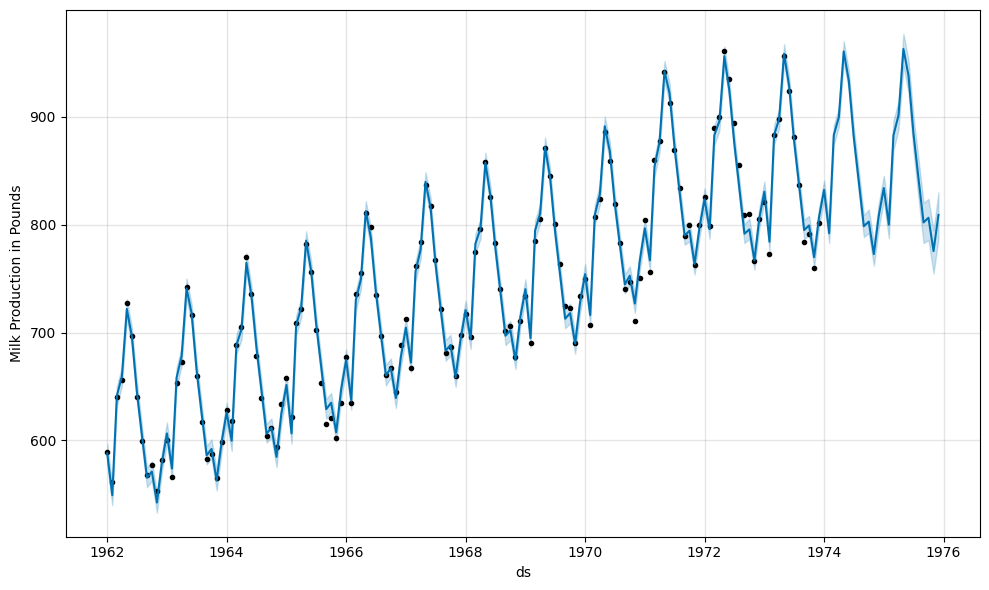

In [82]:
model.plot(forecast, ylabel='Milk Production in Pounds')
plt.show()

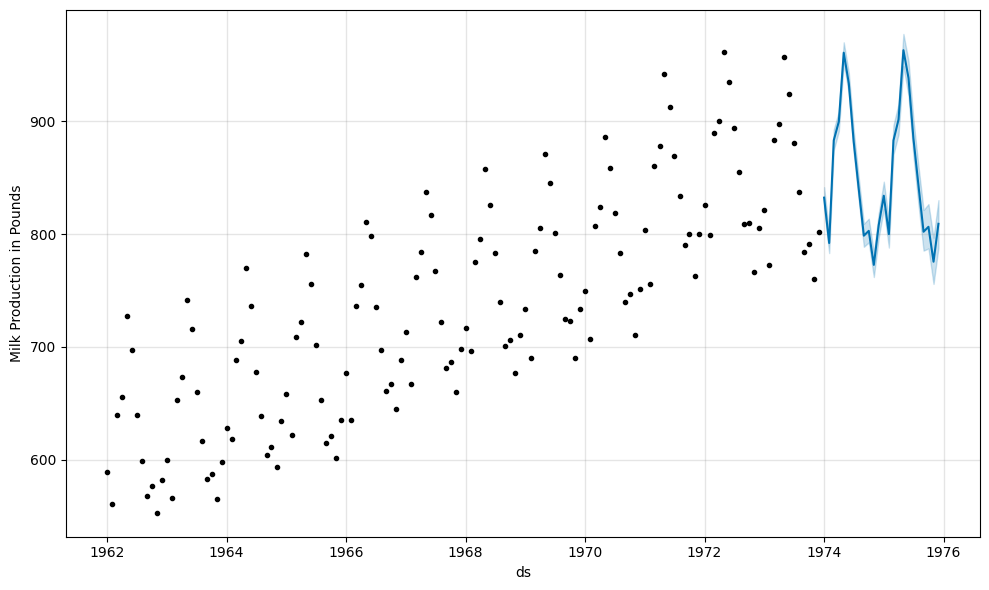

In [83]:
predicted = model.predict(test)
model.plot(predicted, ylabel='Milk Production in Pounds')
plt.show()

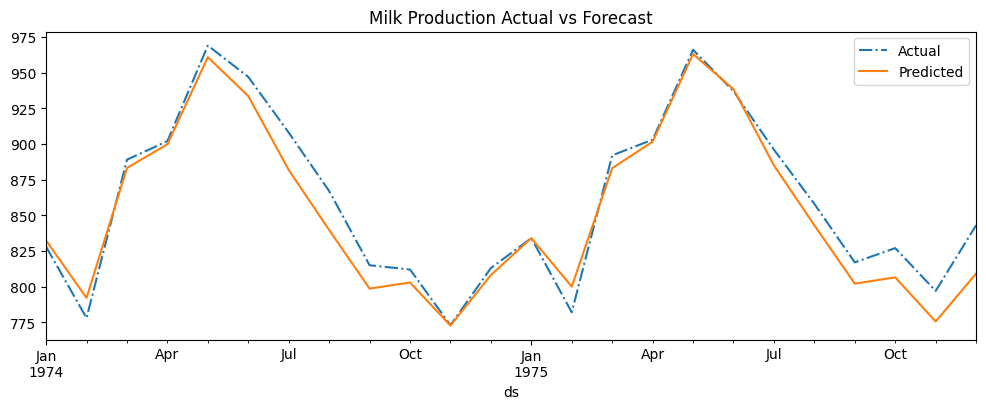

In [84]:
ax = test.plot(x='ds', y='y', 
                    label='Actual', 
                    style='-.', 
                    figsize=(12,4))
predicted.plot(x='ds', y='yhat', 
               label='Predicted', 
               ax=ax)
plt.title('Milk Production Actual vs Forecast')
plt.show()